<a href="https://colab.research.google.com/github/Aryan-baitha/AI-Disease-Predictor/blob/main/Disease_Symptom_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# 1. Load all the CSV files
df_main = pd.read_csv('/content/dataset.csv')
df_desc = pd.read_csv('/content/symptom_Description.csv')
df_prec = pd.read_csv('/content/symptom_precaution.csv')
df_severity = pd.read_csv('/content/Symptom-severity.csv')

# 2. Check the size and the first few rows of the main data
print("Total rows and columns of the dataset:", df_main.shape)
display(df_main.head())

Total rows and columns of the dataset: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Clean the data (Replace NaN with an empty string and remove extra spaces)
df_main = df_main.fillna('')

for col in df_main.columns:
    df_main[col] = df_main[col].astype(str).str.strip()

# 2. Extract all unique symptoms from the dataset
symptoms_list = []
for col in df_main.columns[1:]: # Skip the first column as it is 'Disease'
    symptoms_list.extend(df_main[col].unique())

unique_symptoms = list(set(symptoms_list))
if '' in unique_symptoms:
    unique_symptoms.remove('') # Remove empty values

# 3. Create a new DataFrame (initially filled with 0s)
zero_matrix = np.zeros((len(df_main), len(unique_symptoms)))
df_clean = pd.DataFrame(zero_matrix, columns=unique_symptoms)

# Add the Disease column back to the front
df_clean.insert(0, 'Disease', df_main['Disease'])

# 4. Map the symptoms to 1
for i in range(len(df_main)):
    for col in df_main.columns[1:]:
        symptom = df_main.iloc[i][col]
        if symptom != '':
            df_clean.at[i, symptom] = 1

# 5. Convert disease text labels into numbers (0, 1, 2...)
label_encoder = LabelEncoder()
df_clean['Disease_Encoded'] = label_encoder.fit_transform(df_clean['Disease'])

# The data is ready! Let's print and check it once
print("Shape of the new cleaned data:", df_clean.shape)
display(df_clean.head())

Shape of the new cleaned data: (4920, 133)


,Disease,toxic_look_(typhos),pain_in_anal_region,weight_gain,hip_joint_pain,stomach_bleeding,throat_irritation,spotting_ urination,chills,burning_micturition,...,weakness_of_one_body_side,muscle_pain,yellow_urine,prominent_veins_on_calf,vomiting,continuous_feel_of_urine,neck_pain,excessive_hunger,skin_peeling,Disease_Encoded
0,Fungal infection,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15
1,Fungal infection,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15
2,Fungal infection,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15
3,Fungal infection,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15
4,Fungal infection,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Separate Input Features (X) and Target (y)
# All symptoms except 'Disease' and 'Disease_Encoded' columns are features (X)
X = df_clean.drop(columns=['Disease', 'Disease_Encoded']).values
y = df_clean['Disease_Encoded'].values

# 2. Train-Test Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 3. Build Neural Network Model
model = Sequential()

# Input Layer & First Hidden Layer (128 neurons, ReLU activation)
# input_shape will be equal to our total number of symptoms
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.2)) # To prevent overfitting, 20% of neurons will be randomly dropped

# Second Hidden Layer (64 neurons)
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
# We need as many neurons as the total number of diseases
num_classes = len(label_encoder.classes_)
model.add(Dense(num_classes, activation='softmax')) # Softmax is best for multi-class output

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model (Training starts!)
print("\n--- Model Training Start ---")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))
print("--- Model Training Complete ---\n")

# 6. Test the Accuracy
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy of the Model: **{accuracy * 100:.2f}%**")

Training data shape: (3936, 131)
Testing data shape: (984, 131)

--- Model Training Start ---
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6809 - loss: 2.2748 - val_accuracy: 1.0000 - val_loss: 0.4122
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9891 - loss: 0.2307 - val_accuracy: 1.0000 - val_loss: 0.0248
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9977 - loss: 0.0573 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0302 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0188 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 9.4071e-04
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 6.7896e-04
Epoch 8/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.000

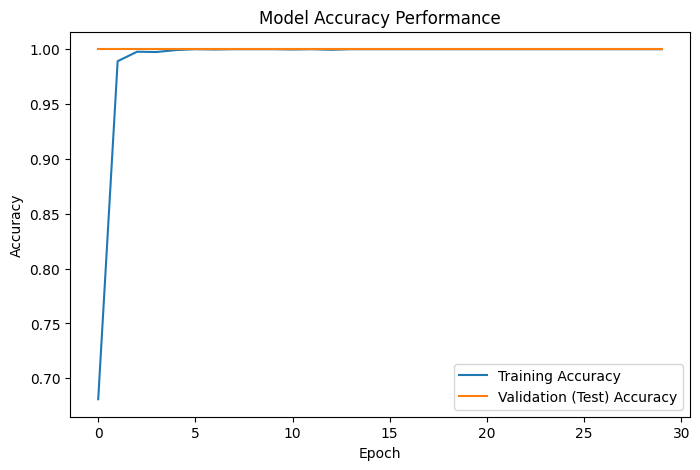

In [5]:
# Accuracy Graph Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy')
plt.title('Model Accuracy Performance')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [6]:
import pickle

# Model ko save karna
model.save('disease_prediction_model.h5')

# Label Encoder ko save karna (taaki numbers ko wapas bimari ke naam mein badal sakein)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Unique symptoms ki list bhi save kar lete hain
with open('symptoms_list.pkl', 'wb') as f:
    pickle.dump(unique_symptoms, f)

print("Model aur configurations save ho gaye hain!")

Model aur configurations save ho gaye hain!


In [7]:
def predict_disease(patient_symptoms):
    print(f"Patient's Symptoms: {patient_symptoms}\n" + "-"*40)

    # 1. Create an array of 0s for input data (according to the model's shape)
    input_data = np.zeros(len(unique_symptoms))

    # 2. Set 1 where the patient has the symptoms
    for symptom in patient_symptoms:
        # Check if the symptom is in our list or not
        symptom = symptom.strip()
        if symptom in unique_symptoms:
            index = unique_symptoms.index(symptom)
            input_data[index] = 1
        else:
            print(f"Warning: '{symptom}' is not in our database.")

    # 3. Reshape the data to (1, total_symptoms)
    input_data = input_data.reshape(1, -1)

    # 4. Get the prediction from the model
    prediction_probs = model.predict(input_data, verbose=0)
    predicted_class = np.argmax(prediction_probs) # Output with the highest probability

    # Convert the number back into the Disease name
    disease_name = label_encoder.inverse_transform([predicted_class])[0]

    # 5. Extract disease details (from the Description dataset)
    description = "Description not available."
    if disease_name in df_desc['Disease'].values:
        description = df_desc[df_desc['Disease'] == disease_name]['Description'].values[0]

    # 6. Extract precautions (from the Precaution dataset)
    precautions = []
    if disease_name in df_prec['Disease'].values:
        # The first column is Disease, the remaining 4 are precautions
        prec_data = df_prec[df_prec['Disease'] == disease_name].values[0][1:]
        # Remove empty (nan) precautions
        precautions = [p for p in prec_data if str(p) != 'nan' and str(p).strip() != '']

    # Print the Final Output
    print(f"🚨 Predicted Disease: **{disease_name}**")
    print(f"📖 Description: {description}")
    print(f"🛡️ Precautions (What to do):")
    for i, p in enumerate(precautions, 1):
        print(f"   {i}. {p.capitalize()}")

print("Prediction Engine is Ready!")

Prediction Engine is Ready!


In [8]:
# Test Case 1: Checking symptoms for Malaria
symptoms_to_test = ['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea']
predict_disease(symptoms_to_test)

print("\n" + "="*50 + "\n")

# Test Case 2: Symptoms similar to Covid/Flu
symptoms_to_test_2 = ['continuous_sneezing', 'chills', 'fatigue', 'cough']
predict_disease(symptoms_to_test_2)

Patient's Symptoms: ['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea']
----------------------------------------
🚨 Predicted Disease: **Malaria**
📖 Description: An infectious disease caused by protozoan parasites from the Plasmodium family that can be transmitted by the bite of the Anopheles mosquito or by a contaminated needle or transfusion. Falciparum malaria is the most deadly type.
🛡️ Precautions (What to do):
   1. Consult nearest hospital
   2. Avoid oily food
   3. Avoid non veg food
   4. Keep mosquitos out


Patient's Symptoms: ['continuous_sneezing', 'chills', 'fatigue', 'cough']
----------------------------------------
🚨 Predicted Disease: **Allergy**
📖 Description: An allergy is an immune system response to a foreign substance that's not typically harmful to your body.They can include certain foods, pollen, or pet dander. Your immune system's job is to keep you healthy by fighting harmful pathogens.
🛡️ Precautions (What to do):
   1. Apply calamine
   2.

In [9]:
!pip install streamlit -q
!npm install localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 30.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 3s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [10]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf

# 1. Load Saved Files
@st.cache_resource
def load_model():
    return tf.keras.models.load_model('disease_prediction_model.h5')

model = load_model()

with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open('symptoms_list.pkl', 'rb') as f:
    unique_symptoms = pickle.load(f)

df_desc = pd.read_csv('symptom_Description.csv')
df_prec = pd.read_csv('symptom_precaution.csv')

# 2. Web UI Design
st.set_page_config(page_title="AI Disease Predictor", page_icon="🩺")
st.title("🩺 AI Disease Predictor")
st.write("Select the patient's symptoms and our Deep Learning model will predict the disease.")

# Multiselect box for user input
selected_symptoms = st.multiselect("Select Symptom(s):", unique_symptoms)

# Predict Button
if st.button("Predict Disease", type="primary"):
    if len(selected_symptoms) > 0:
        # Prepare input data
        input_data = np.zeros(len(unique_symptoms))
        for symptom in selected_symptoms:
            if symptom in unique_symptoms:
                index = unique_symptoms.index(symptom)
                input_data[index] = 1

        input_data = input_data.reshape(1, -1)

        # Model Prediction
        prediction_probs = model.predict(input_data, verbose=0)
        predicted_class = np.argmax(prediction_probs)
        disease_name = label_encoder.inverse_transform([predicted_class])[0]

        # Extract details from CSV
        desc = "Description not available."
        if disease_name in df_desc['Disease'].values:
            desc = df_desc[df_desc['Disease'] == disease_name]['Description'].values[0]

        precautions = []
        if disease_name in df_prec['Disease'].values:
            prec_data = df_prec[df_prec['Disease'] == disease_name].values[0][1:]
            precautions = [p for p in prec_data if str(p) != 'nan' and str(p).strip() != '']

        # Display the Result
        st.divider()
        st.error(f"### 🚨 Predicted Disease: {disease_name.upper()}")
        st.info(f"**📖 Description:** {desc}")

        if precautions:
            st.warning("**🛡️ Recommended Precautions:**")
            for i, p in enumerate(precautions, 1):
                st.write(f"{i}. {p.capitalize()}")
    else:
        st.error("⚠️ Please select at least one symptom to run the model!")

Writing app.py


In [11]:
import urllib

# 1. Get the IP address of the Colab server (This will be your password)
ip_address = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print(f"👉 NOTE: Your Tunnel Password is this IP: {ip_address}")
print("Click on the link provided below and paste this password in the box.\n")

# 2. Run the Streamlit app in the background
!streamlit run app.py &>/content/logs.txt &

# 3. Create a tunnel
!npx localtunnel --port 8501

👉 NOTE: Your Tunnel Password is this IP: 34.57.104.185
Click on the link provided below and paste this password in the box.

⠙⠹your url is: https://brown-turtles-cheat.loca.lt
^C
